In [42]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas. Prophet listo para la acción.")

✅ Librerías importadas. Prophet listo para la acción.


In [44]:
print("--- 1. CARGA DE DATOS Y BÚSQUEDA DEL TOP 3 ---")
anios = range(2018, 2027)
df_list = []

for anio in anios:
    nombre_archivo = f"venta {anio}.xls"
    temp_df = None
    try:
        temp_df = pd.read_excel(nombre_archivo)
        print(f"✅ {nombre_archivo}: Cargado como Excel")
    except Exception:
        try:
            temp_df = pd.read_csv(nombre_archivo, encoding="latin-1", on_bad_lines='skip')
            print(f"✅ {nombre_archivo}: Cargado como CSV")
        except Exception:
            pass # Si falla, ignoramos y seguimos

    if temp_df is not None:
        df_list.append(temp_df)

data_completa = pd.concat(df_list, ignore_index=True)
data_completa['cantidad'] = data_completa['cantidad'] / 50

print("¡Datos cargados y convertidos a sacos exitosamente!")
print(f"\nTotal de filas en el historial: {len(data_completa)}")

# =====================================================================
# NUEVO: CARGAR Y PREPARAR VARIABLES EXÓGENAS
# =====================================================================
print("Cargando variables exógenas...")
df_exo = pd.read_excel("Variables exogenas final.xlsx")

# Convertimos la columna 'Mes/Año' a formato de fecha de Python
df_exo['Fecha'] = pd.to_datetime(df_exo['Mes/Año'])

# Extraemos el Año y el Mes para que sea súper fácil cruzarlo con nuestras ventas
df_exo['year'] = df_exo['Fecha'].dt.year
df_exo['month'] = df_exo['Fecha'].dt.month

# Nos quedamos solo con las columnas que nos importan
df_exo = df_exo[['year', 'month', 'Precio_Urea_MAG', 'Promedio_precipitaciones_Pichincha', 'Evento_Excepcion']]

print("¡Variables exógenas listas para integrarse!")

# Descubrir el TOP 3 de productos más vendidos
top_productos = data_completa.groupby('nomart')['cantidad'].sum().sort_values(ascending=False).head(3)

print("\n🏆 EL TOP 3 DE PRODUCTOS ESTRELLA ES:")
for i, (nombre, cantidad) in enumerate(top_productos.items(), 1):
    print(f"{i}. {nombre} ({cantidad:,.0f} sacos vendidos)")

# Guardar los nombres en una lista para el bucle
lista_top_3 = top_productos.index.tolist()

--- 1. CARGA DE DATOS Y BÚSQUEDA DEL TOP 3 ---
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2018.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2019.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2020.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2021.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ venta 2022.xls: Cargado como Excel
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is


██████████████████████████████████████████████████████████████████████
🚀 PROPHET: INICIANDO ANÁLISIS PARA:
   SULFATO DE CALCIO/YESO AGRICOLA 50 KG (NACIONAL)
   📈 ESTRATEGIA: Modelo Univariante Prophet (SIN Variables Exógenas)
██████████████████████████████████████████████████████████████████████

--- MÉTRICAS SULFATO DE CALC ---
Exactitud Prophet: 39.94%
Error MAE:         420 sacos


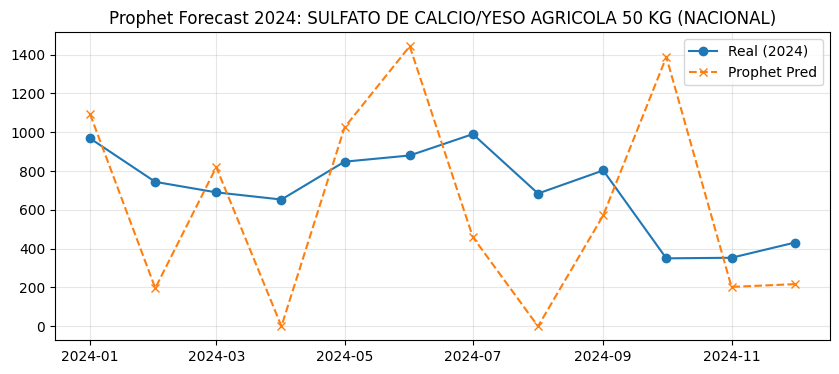

Generando componentes del modelo...


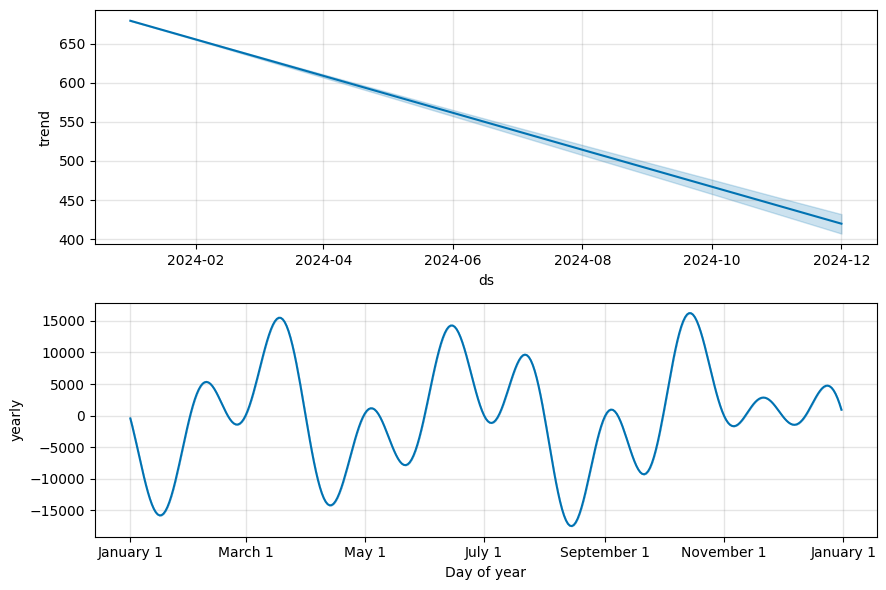

✅ Modelo Prophet guardado como: prophet_modelo_SULFATO DE CALC.pkl


██████████████████████████████████████████████████████████████████████
🚀 PROPHET: INICIANDO ANÁLISIS PARA:
   CARBONATO DE CALCIO/CAL AGRICOLA 50 KG
   🧠 ESTRATEGIA: Modelo Causal Prophet (CON Variables Exógenas)
██████████████████████████████████████████████████████████████████████

--- MÉTRICAS CARBONATO DE CA ---
Exactitud Prophet: 75.20%
Error MAE:         293 sacos


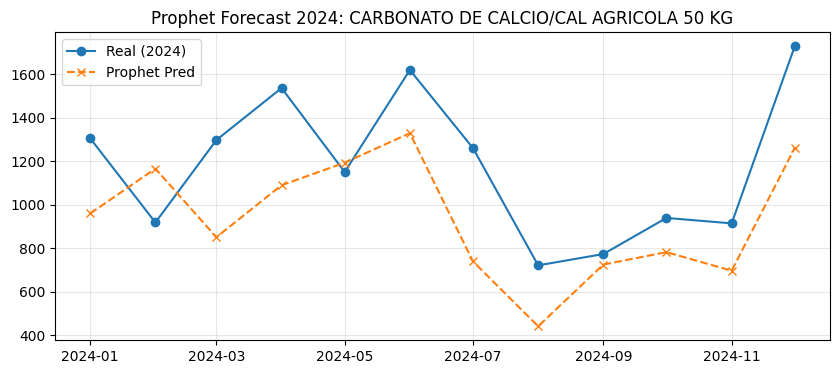

Generando componentes del modelo...


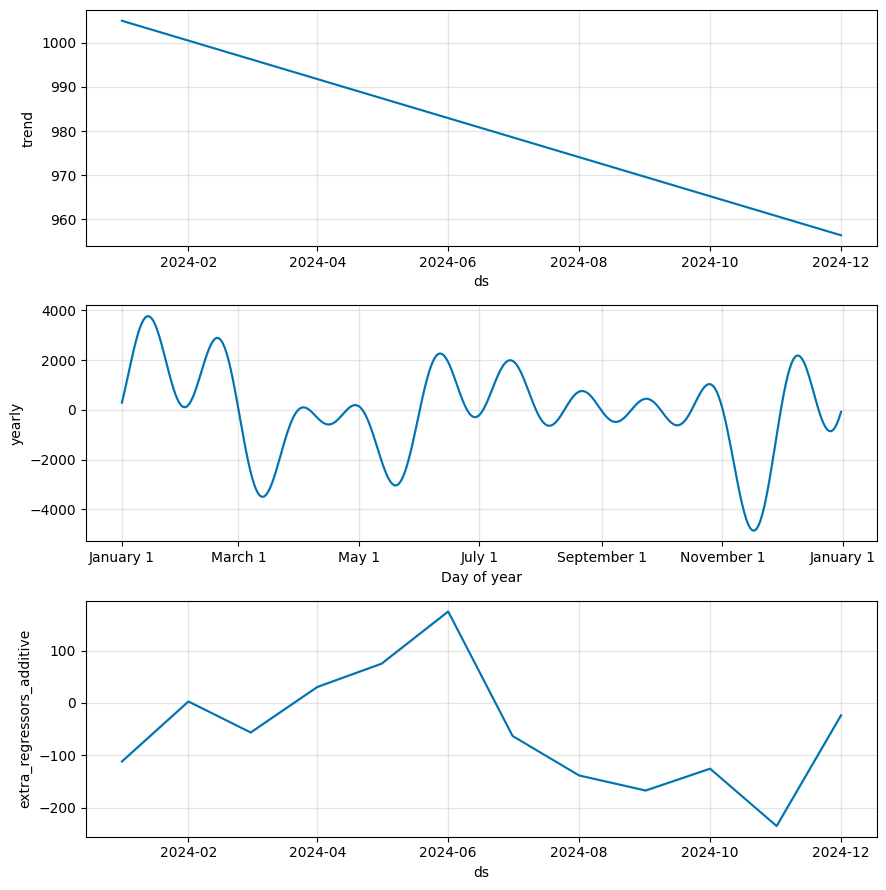

✅ Modelo Prophet guardado como: prophet_modelo_CARBONATO DE CA.pkl


██████████████████████████████████████████████████████████████████████
🚀 PROPHET: INICIANDO ANÁLISIS PARA:
   CALDOLOMITA 50 KG (NACIONAL)
   🧠 ESTRATEGIA: Modelo Causal Prophet (CON Variables Exógenas)
██████████████████████████████████████████████████████████████████████

--- MÉTRICAS CALDOLOMITA 50  ---
Exactitud Prophet: 50.05%
Error MAE:         165 sacos


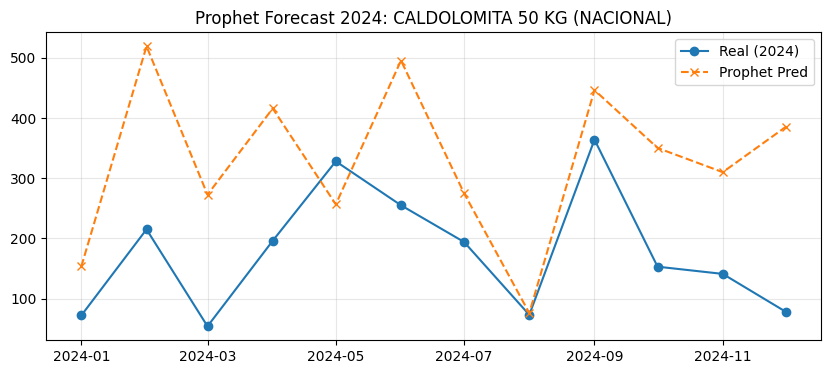

Generando componentes del modelo...


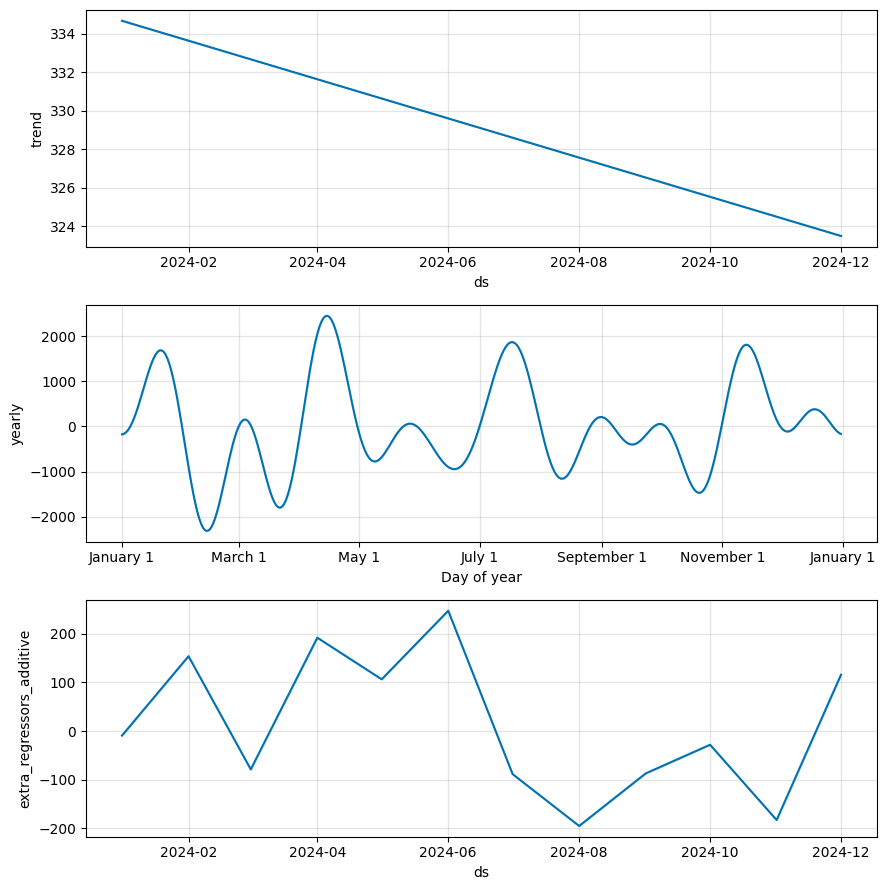

✅ Modelo Prophet guardado como: prophet_modelo_CALDOLOMITA 50 .pkl



In [48]:
# Diccionario para guardar el resumen final
resultados_finales = {}

for producto in lista_top_3:
    print("\n" + "█"*70)
    print(f"🚀 PROPHET: INICIANDO ANÁLISIS PARA:\n   {producto}")

    # Determinamos si usamos variables exógenas
    usar_exogenas = True if "CALDOLOMITA" in producto or "CARBONATO" in producto else False

    if usar_exogenas:
        print("   🧠 ESTRATEGIA: Modelo Causal Prophet (CON Variables Exógenas)")
    else:
        print("   📈 ESTRATEGIA: Modelo Univariante Prophet (SIN Variables Exógenas)")
    print("█" * 70)

    # 1. PREPARACIÓN DE DATOS (Filtrado por producto)
    data_prod = data_completa[data_completa['nomart'] == producto].copy()

    # Función de limpieza de fechas
    def convertir_fecha(valor):
        if isinstance(valor, pd.Timestamp) or pd.api.types.is_datetime64_any_dtype(type(valor)):
            return valor
        try: return pd.to_datetime(float(valor), origin='1899-12-30', unit='D')
        except: return pd.to_datetime(valor, errors='coerce')

    data_prod['fecha_real'] = data_prod['emision'].apply(convertir_fecha)

    # SOLUCIÓN AL ERROR: Renombrar los niveles del groupby para evitar colisión de nombres
    demanda_mensual = data_prod.groupby([
        data_prod['fecha_real'].dt.year.rename('year'),
        data_prod['fecha_real'].dt.month.rename('month')
    ]).agg(
        cantidad=('cantidad', 'sum')
    ).reset_index()

    # Continuar con el formateo para Prophet
    demanda_mensual['ds'] = pd.to_datetime(
        demanda_mensual[['year', 'month']].assign(day=1)
    )
    demanda_mensual = demanda_mensual.rename(columns={'cantidad': 'y'})
    demanda_mensual = demanda_mensual[['ds', 'y']].sort_values('ds')

    # Integración de variables exógenas (Urea, Clima, etc.)
    demanda_mensual['year'] = demanda_mensual['ds'].dt.year
    demanda_mensual['month'] = demanda_mensual['ds'].dt.month
    demanda_mensual = pd.merge(demanda_mensual, df_exo, how='left', on=['year', 'month'])
    demanda_mensual.fillna(method='ffill', inplace=True)
    demanda_mensual.fillna(0, inplace=True)

    # 2. DIVISIÓN TRAIN/TEST (Validación 2024)
    train = demanda_mensual[demanda_mensual['ds'].dt.year < 2024]
    test = demanda_mensual[demanda_mensual['ds'].dt.year == 2024]

    # 3. CONFIGURACIÓN DEL MODELO PROPHET
    # Ajustamos la estacionalidad anual ya que los datos son de ventas agrícolas
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

    if usar_exogenas:
        model.add_regressor('Precio_Urea_MAG')
        model.add_regressor('Promedio_precipitaciones_Pichincha')
        model.add_regressor('Evento_Excepcion')

    # 4. ENTRENAMIENTO
    model.fit(train)

    # 5. PREDICCIÓN
    forecast = model.predict(test)
    y_pred = np.maximum(forecast['yhat'].values, 0) # No permitir valores negativos
    y_test = test['y'].values

    # 6. MÉTRICAS
    mae = mean_absolute_error(y_test, y_pred)
    suma_errores_absolutos = np.sum(np.abs(y_test - y_pred))
    denominador = max(np.sum(y_test), np.sum(y_pred)) if np.sum(y_test) != 0 or np.sum(y_pred) != 0 else 1 # Avoid division by zero
    exactitud = max(0, 100 - (suma_errores_absolutos / denominador * 100)) if denominador > 0 else 0

    resultados_finales[producto] = {'Exactitud': exactitud, 'MAE': mae}

    print(f"\n--- MÉTRICAS {producto[:15]} ---")
    print(f"Exactitud Prophet: {exactitud:.2f}%")
    print(f"Error MAE:         {mae:,.0f} sacos")

    # 7. GRÁFICOS
    # Gráfico de Realidad vs Predicción
    plt.figure(figsize=(10, 4))
    plt.plot(test['ds'], y_test, marker='o', label='Real (2024)', color='#1f77b4')
    plt.plot(test['ds'], y_pred, marker='x', linestyle='--', label='Prophet Pred', color='#ff7f0e')
    plt.title(f'Prophet Forecast 2024: {producto}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Gráfico de Componentes (Tendencia y Estacionalidad)
    print("Generando componentes del modelo...")
    model.plot_components(forecast)
    plt.show()

    # 8. GUARDAR MODELO
    nombre_limpio = "".join([c for c in producto if c.isalpha() or c.isdigit() or c==' ']).rstrip()
    joblib.dump(model, f'prophet_modelo_{nombre_limpio[:15]}.pkl')
    print(f"✅ Modelo Prophet guardado como: prophet_modelo_{nombre_limpio[:15]}.pkl\n")